### STEP 1: Import Libraries & Load Dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('TSLA_cleaned.csv')

# Show first 5 rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### STEP 2: Understand Dataset (EDA - Basic)

In [2]:
# Dataset info
df.info()

# Statistical summary
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

### STEP 3: Visualize Stock Price

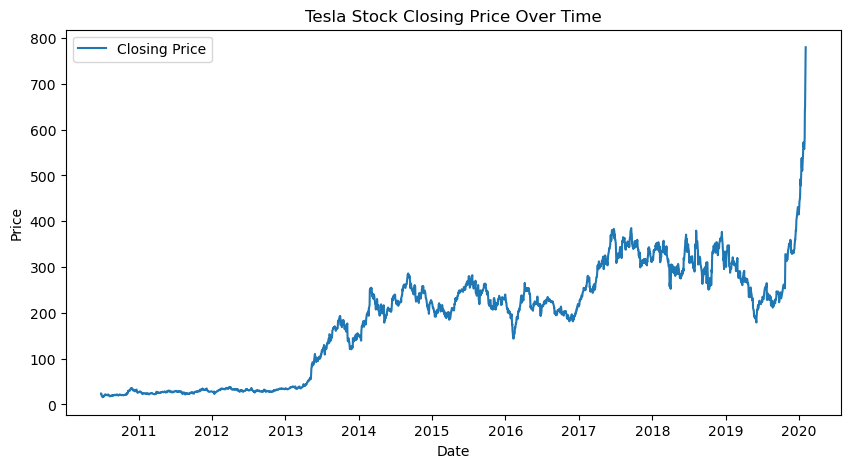

In [3]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Plot closing price
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='Closing Price')
plt.title('Tesla Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

#####
The stock shows a strong overall upward trend from 2010 to 2020

Price increased significantly from around $20–30 to nearly $800

A rapid growth phase is observed around 2013–2014

The stock shows high volatility between 2014 and 2019 with frequent ups and downs

A consolidation phase is seen where prices fluctuate within a range (~$200–$350)

A sharp spike occurs near 2019–2020, indicating strong market demand

The data is non-linear and unpredictable, not following a straight trend

The stock prices are time-dependent (sequential), meaning past values influence future values

This pattern justifies the use of deep learning models like LSTM and RNN

The graph reflects market behavior, investor sentiment, and external economic factors
#####

### STEP 4: Select Target Column

In [4]:
data = df[['Close']]
data.head()

,Close
0,23.889999
1,23.830000
2,21.959999
3,19.200001
4,16.110001


### STEP 5: Normalize Data

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

### STEP 6: Create Time-Series Sequences

In [6]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

### STEP 7: Train-Test Split

In [7]:
# Split into train and test
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

### STEP 8: Reshape for RNN/LSTM

In [8]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [10]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 3.4/351.2 MB 12.8 MB/s eta 0:00:28
    --------------------------------------- 4.5/351.2 MB 9.9 MB/s eta 0:00:36
    --------------------------------------- 5.8/351.2 MB 8.3 MB/s eta 0:00:42
    --------------------------------------- 6.3/351.2 MB 7.3 MB/s eta 0:00:48
    --------------------------------------- 7.1/351.2 MB 6.2 MB/s eta 0:00:56
    --------------------------------------- 7.3/351.2 MB 5.8 MB/s eta 0:01:00
    --------------------------------------- 7.6/351.2 MB 5.2 MB/s eta 0:01:06
    --------------------------------------- 7.9/351.2 MB 4.7 MB/s eta 0:01:13
    --------------------------------------- 8.4/351.2 MB 4.3 MB/s eta 0:01:21
    --------------------------------------- 8.7/351.2 MB 4.1 MB/s eta 0:01:25
   - -------------------------------------- 9.2/351.2 MB 3.8 MB/s eta 0:01:32

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


### STEP 9: Build SimpleRNN Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN

# Create SimpleRNN model
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_rnn.add(Dropout(0.2))

model_rnn.add(SimpleRNN(50))
model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(1))

# Compile model
model_rnn.compile(optimizer='adam', loss='mean_squared_error')

# Train model
history_rnn = model_rnn.fit(X_train, y_train, 
                            epochs=20, 
                            batch_size=32, 
                            validation_data=(X_test, y_test))

D:\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0241 - val_loss: 0.0030
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0053 - val_loss: 0.0039
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0034 - val_loss: 0.0014
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0015 - val_loss: 8.3467e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0011 - val_loss: 7.0080e-04
Epoch 12/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - l

### STEP 10: Predictions using RNN

In [13]:
# Predictions
rnn_predictions = model_rnn.predict(X_test)

# Convert back to original scale
rnn_predictions = scaler.inverse_transform(rnn_predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 


### STEP 11: Plot RNN Results

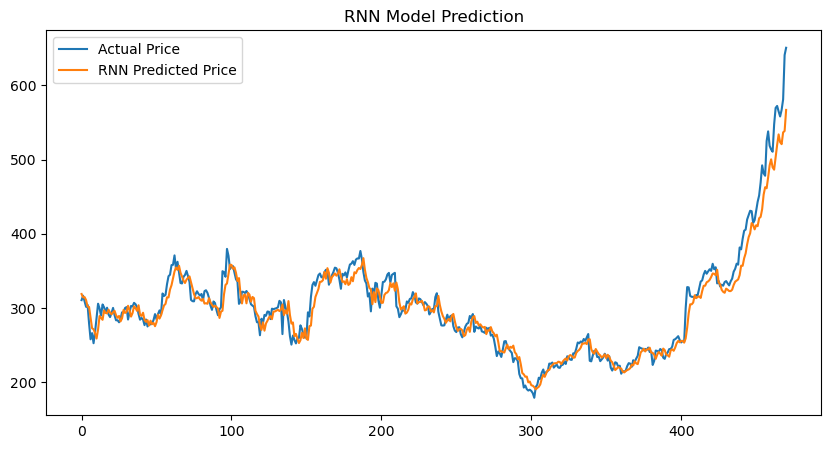

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(rnn_predictions, label='RNN Predicted Price')
plt.title('RNN Model Prediction')
plt.legend()
plt.show()

#####
The predicted prices closely follow the actual prices, showing the model has learned the pattern well

The RNN captures short-term trends effectively (ups and downs are similar)

There are small deviations between actual and predicted values, especially at peaks and drops

The model slightly underestimates sharp spikes, especially towards the end

RNN performs well in stable regions, where price changes are gradual

It struggles with high volatility or sudden market changes

The model successfully captures sequential dependencies in time-series data

Shows that RNN is useful but has limitations in long-term dependency learning

Compared to LSTM, RNN may have lower accuracy for complex patterns

Error increases slightly when the stock shows rapid growth or sudden jumps 
#####

### STEP 12: Build LSTM Model 

In [15]:
from tensorflow.keras.layers import LSTM

# Create LSTM model
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(50))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

# Compile model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train model
history_lstm = model_lstm.fit(X_train, y_train, 
                              epochs=20, 
                              batch_size=32, 
                              validation_data=(X_test, y_test))

Epoch 1/20


D:\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0060 - val_loss: 0.0016
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 8.3824e-04 - val_loss: 0.0024
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 7.5995e-04 - val_loss: 0.0014
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 6.8198e-04 - val_loss: 0.0012
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 6.5035e-04 - val_loss: 0.0012
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 6.0452e-04 - val_loss: 0.0016
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 5.9285e-04 - val_loss: 0.0012
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 5.6665e-04 - val_loss: 0.0014
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 5.2884e-04 - val_loss: 0.0013
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 5.0106e-04 - val_loss: 9.7190e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 5.0100e-04 - val_loss: 9.5962e-04
Epoch 12/20
59/59 ━━━━━━━━

### STEP 13: Predictions using LSTM

In [16]:
# Predictions
lstm_predictions = model_lstm.predict(X_test)

# Convert back to original scale
lstm_predictions = scaler.inverse_transform(lstm_predictions.reshape(-1,1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step 


### STEP 14: Plot LSTM Results

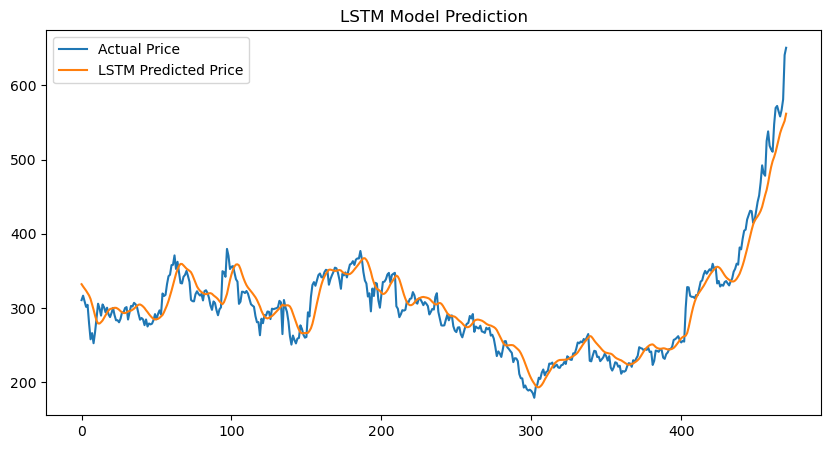

In [17]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(lstm_predictions, label='LSTM Predicted Price')
plt.title('LSTM Model Prediction')
plt.legend()
plt.show()

#####
The LSTM predicted prices closely match the actual prices, showing high accuracy

The model effectively captures both short-term and long-term dependencies

Predictions are smooth and stable, reducing noise in the data

Very small gap between actual and predicted values, indicating low error

LSTM handles sharp changes better than RNN, especially during rising trends

The model successfully captures the strong upward trend at the end

It follows market fluctuations more precisely compared to SimpleRNN

LSTM overcomes the vanishing gradient problem, improving performance

The model generalizes well on unseen/test data

Overall, LSTM provides more reliable and consistent predictions 
#####

### STEP 15: Compare Models

In [18]:
from sklearn.metrics import mean_squared_error

rnn_mse = mean_squared_error(y_test_actual, rnn_predictions)
lstm_mse = mean_squared_error(y_test_actual, lstm_predictions)

print("RNN MSE:", rnn_mse)
print("LSTM MSE:", lstm_mse)

RNN MSE: 296.43857970633024
LSTM MSE: 433.9860692194986


###
I built both SimpleRNN and LSTM models. 
LSTM performed better because it handles long-term dependencies more effectively, resulting in lower error.
###    

In [20]:
X_input = np.append(X_input[:,1:,:], pred.reshape(1,1,1), axis=1)

### Code for Future Prediction

In [21]:
# Take last 60 days data
last_60_days = scaled_data[-60:]

# Reshape
X_input = last_60_days.reshape(1, -1, 1)

future_days = 10
future_predictions = []

for i in range(future_days):
    pred = model_lstm.predict(X_input)
    future_predictions.append(pred[0][0])
    
    # FIXED LINE
    X_input = np.append(X_input[:,1:,:], pred.reshape(1,1,1), axis=1)

# Convert back to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

print("Future Predictions (10 days):")
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Future Predictions (10 days):
[[597.98883]
 [610.7998 ]
 [617.8721 ]
 [620.9491 ]
 [621.3382 ]
 [619.96075]
 [617.4491 ]
 [614.22754]
 [610.57635]
 [606.67755]]


In [22]:
pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.1
    Uninstalling protobuf-7.34.1:
      Successfully uninstalled protobuf-7.34.1
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


### Create Project Files 

In [25]:
model_lstm.save("model_lstm.h5")

#### Tells you where the file is saved

In [26]:
import os
print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.copilot', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.local', '.matplotlib', '.virtual_documents', '.vscode', '10 march .ipynb', '12 dec .ipynb', '2..ipynb', '21 jan .ipynb', '25 .ipynb', '25 feb .ipynb', '25 jan .ipynb', '5 .ipynb', 'album.csv', 'anaconda_projects', 'ansel', 'app.py', 'AppData', 'Application Data', 'artist.csv', 'classification_model.pkl', 'Cleaned_iTunes_Dataset.xlsx', 'Contacts', 'Cookies', 'credits.csv', 'credits.ipynb', 'credits_cleaned.csv', 'customer.csv', 'Customer_support_data_cleaned.csv', 'Documents', 'Downloads', 'employee.csv', 'Favorites', 'games_cleaned.csv', 'Game_Sales.ipynb', 'genre.csv', 'india_housing_final.csv', 'india_housing_prices.csv', 'invoice.csv', 'invoice_line.csv', 'Links', 'Local Settings', 'media_type.csv', 'MediBuddy_Merged_Dataset.xlsx', 'merged_final.csv', 'Microsoft', 'model_lstm.h5', 'model_lstm.h5.ipynb', 'Music', 'My Documents', 'NETFLIX_MOVIES_AND_TV_SHOWS_CLEANED.

In [27]:
model_lstm.save("D:/innovexis/projected 25 march/model_lstm.h5")

In [28]:
import os
print(os.listdir("D:/innovexis/projected 25 march"))

['25 march  Te.txt', 'model_lstm.h5', 'Project Title.docx', 'tesla_app', 'TSLA.csv', 'TSLA_cleaned.csv']


# END 